In [1]:
import sys
import os

from xxybacktest import run_backtest
from xxybacktest.types import Context
from xxybacktest.trading import order_target_percent
from xxydb import xxydb

def initial(context: Context):
    # # 获取数据
    # sql = f"""
    # with t1 as (
    #     SELECT date, instrument, total_market_cap AS cap, dividend_yield_ratio, 
    #     RANK() OVER (PARTITION BY date ORDER BY dividend_yield_ratio DESC) / COUNT(*) OVER (PARTITION BY date) AS rank_ratio, 
    #     FROM valuation
    #     INNER JOIN daily_bar USING (date, instrument) 
    #     INNER JOIN stock_status USING (date, instrument) 
    #     WHERE close <= 20 AND 
    #     -- list_days >= 200 AND 
    #     st_status = 0 AND 
    #     suspended = 0 AND 
    #     list_sector = 1 and
    #     is_risk_warning = 0 and
    #     instrument != '603122.SH' and
    #     date >= '{context.trade.start_time}' and 
    #     date <= '{context.trade.end_time}'

    #     QUALIFY rank_ratio < 0.25
    # )
    # select date, instrument, c_pct_rank(cap) as score
    # from t1
    # order by date, score, dividend_yield_ratio DESC    
    # """
    # conn = xxydb(path=context.data.data_path)
    # context.df = conn.query(sql=sql).df()
    # print(context.df.head(5))
    
    context.g.day_count = -1

def handle_data(context: Context):
    # context.g.day_count += 1
    # if context.g.day_count % 22 != 0:
    #     return
    # df = context.df[context.df['date']==context.current_dt.strftime("%Y-%m-%d")].sort_values("total_market_cap").head(5)
    # target = list(df['instrument'])

    # positions = {k: v for k, v in context.portfolio.positions.items() if v.amount > 0}
    # holding = list(positions.keys())

    # print(context.current_dt)

    order_target_percent('601288.SH', 1, context)

    # print(context.current_dt, holding)

    # for ins in holding:
    #     if ins not in target:
    #         order_target_percent(ins, 0, context)

    # for ins in target:
    #     if ins not in holding:
    #         order_target_percent(ins, 1 / 5, context)
    

result = run_backtest(
    initialize=initial, 
    handle_data=handle_data, 
    start_date='2019-01-01', 
    end_date='2026-02-05',
    data_path=r"E:\回测框架复现\backtest_Reproduction\data", 
    capital=10000000
)

print(result.performance)

CatalogException: Catalog Error: Table with name daily_bar does not exist!
Did you mean "sqlite_master"?

LINE 7:             FROM daily_bar d
                         ^

<Axes: >

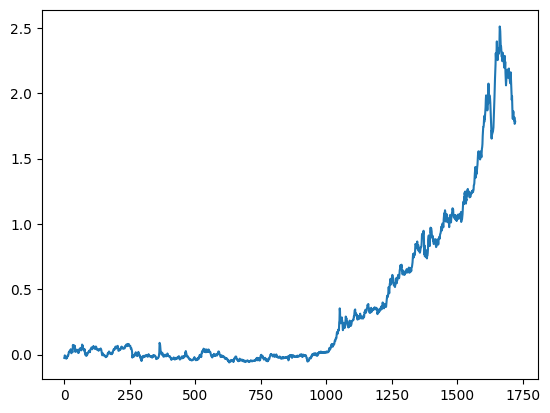

In [2]:
import pandas as pd

((pd.DataFrame(result.performance.returns)[1]).cumprod() - 1).plot()